# XGBoost Ensemble — Predicting Popularity

**Target**: `Popularity` (integer, range −65 to 100)  
**Split**: 80% train / 10% val / 10% test  
**Metric**: RMSE, R², MAE

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

## Load Data

In [2]:
df = pd.read_parquet('puzzles_features.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000000, 90)


,Rating,RatingDeviation,Popularity,NbPlays,num_moves,num_openings,num_themes,has_mate,total_material,material_balance,...,masterVsMaster,hookMate,castling,doubleBishopMate,short,crushing,equality,kingsideAttack,sacrifice,backRankMate
0,1344,76,90,1728,4,2,5,False,7000,0,...,0,0,0,0,1,1,0,0,0,0
1,1526,76,96,22662,6,0,5,False,1400,0,...,0,0,0,0,0,1,0,0,0,0
2,2213,75,97,1240,6,0,5,False,1100,100,...,0,0,0,0,0,1,0,0,0,0
3,1055,81,85,196,4,0,4,False,2200,0,...,0,0,0,0,1,0,0,0,0,0
4,962,91,83,86,4,0,6,False,4200,0,...,0,0,0,0,1,1,0,0,0,0


## Data Analysis

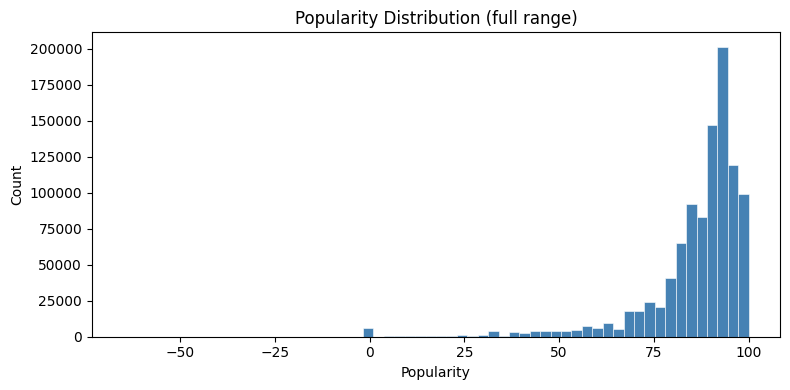

count    1000000.00
mean          86.11
std           14.21
min          -65.00
25%           83.00
50%           90.00
75%           94.00
max          100.00
Name: Popularity, dtype: float64


In [27]:
fig, axes = plt.subplots(1, figsize=(8, 4))

axes.hist(df['Popularity'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes.set_title('Popularity Distribution (full range)')
axes.set_xlabel('Popularity')
axes.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df['Popularity'].describe().round(2))

## Data Processing

In [13]:
DROP_COLS = ['Popularity']

X = df.drop(columns=DROP_COLS)
y = df['Popularity'].astype(float)

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

# Train test split:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')


Features: 89
Samples:  1000000
Train: 800,000  |  Val: 100,000  |  Test: 100,000


## Training & Hyperparameter Tuning

In [33]:
param_grid = [
    {'max_depth': 4,  'learning_rate': 0.1,  'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 6,  'learning_rate': 0.1,  'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 8,  'learning_rate': 0.1,  'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 6,  'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 6,  'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 8,  'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 8,  'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 1.0, 'colsample_bytree': 1.0},
    {'max_depth': 8, 'learning_rate' : 0.05, 'n_estimators' : 1000, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 8, 'learning_rate' : 0.05, 'n_estimators' : 1000, 'subsample': 1.0, 'colsample_bytree': 1.0}
]

results = []
for params in param_grid:
    xgb = XGBRegressor(
        n_jobs=-1,
        random_state=SEED,
        tree_method='hist',
        **params
    )
    xgb.fit(X_train, y_train)
    preds = xgb.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae  = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    results.append({**params, 'Val RMSE': round(rmse, 4), 'Val MAE': round(mae, 4), 'Val R^2': round(r2, 4), 'XGB' : xgb})
    
    print(f"depth={params['max_depth']}  lr={params['learning_rate']}  "
          f"trees={params['n_estimators']}  ss={params['subsample']}  "
          f"cs={params['colsample_bytree']}  →  RMSE={rmse:.4f}  MAE={mae:.4f}  R^2={r2:.4f}")

depth=4  lr=0.1  trees=200  ss=0.8  cs=0.8  →  RMSE=10.6882  MAE=6.4188  R^2=0.4379
depth=6  lr=0.1  trees=200  ss=0.8  cs=0.8  →  RMSE=10.6128  MAE=6.3292  R^2=0.4458
depth=8  lr=0.1  trees=200  ss=0.8  cs=0.8  →  RMSE=10.6117  MAE=6.2855  R^2=0.4460
depth=6  lr=0.05  trees=300  ss=0.8  cs=0.8  →  RMSE=10.6222  MAE=6.3395  R^2=0.4449
depth=6  lr=0.05  trees=500  ss=0.8  cs=0.8  →  RMSE=10.6078  MAE=6.3213  R^2=0.4464
depth=8  lr=0.05  trees=500  ss=0.8  cs=0.8  →  RMSE=10.5886  MAE=6.2703  R^2=0.4484
depth=8  lr=0.05  trees=500  ss=1.0  cs=1.0  →  RMSE=10.5798  MAE=6.2673  R^2=0.4493
depth=8  lr=0.05  trees=1000  ss=0.8  cs=0.8  →  RMSE=10.6326  MAE=6.2749  R^2=0.4438
depth=8  lr=0.05  trees=1000  ss=1.0  cs=1.0  →  RMSE=10.6084  MAE=6.2622  R^2=0.4463


In [32]:
results_df = pd.DataFrame(results)

best_idx = results_df['Val RMSE'].idxmin()
best_params = results_df.iloc[best_idx]
xgb_final = best_params['XGB']

print(f"\nBest params: depth={int(best_params['max_depth'])}, "
      f"lr={best_params['learning_rate']}, "
      f"trees={int(best_params['n_estimators'])}, "
      f"subsample={best_params['subsample']}, "
      f"colsample_bytree={best_params['colsample_bytree']}")


Best params: depth=8, lr=0.05, trees=500, subsample=1.0, colsample_bytree=1.0


## Evaluation

In [22]:
y_test_pred = xgb_final.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print(f'{"":20s}  {"RMSE":>8s}  {"R²":>8s}')
print(f'{"Test":20s}  {test_rmse:>8.4f}  {test_r2:>8.4f}')

                          RMSE        R²
Test                   10.5297    0.4487


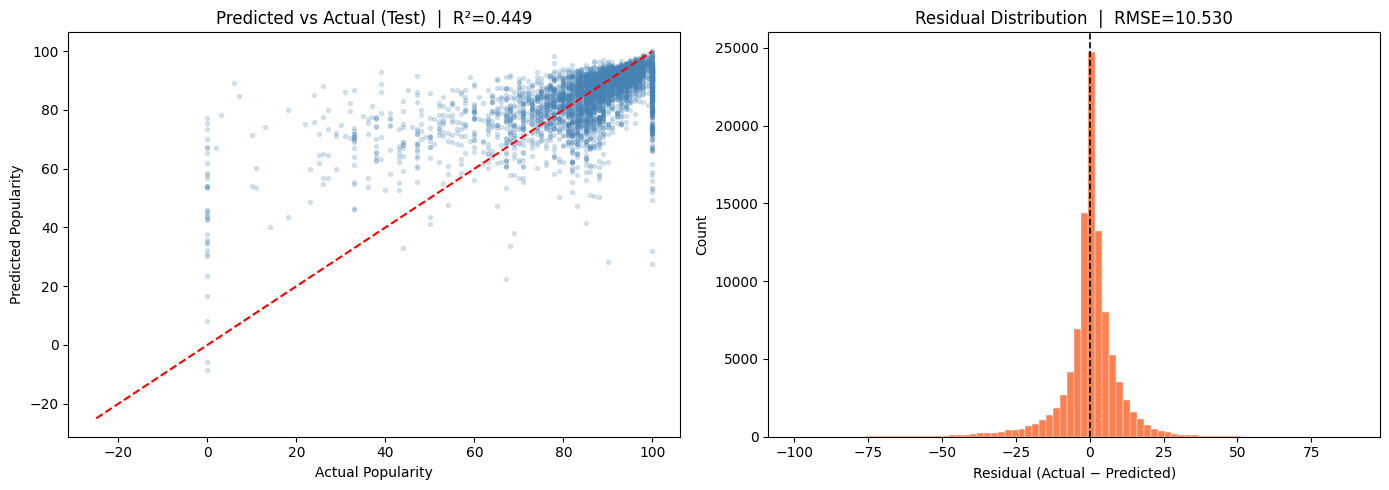

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred[sample_idx], alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Predicted vs Actual (Test)  |  R²={test_r2:.3f}')

# Residuals
residuals = y_test.values - y_test_pred
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  RMSE={test_rmse:.3f}')

plt.tight_layout()
plt.show()

## Result Analysis

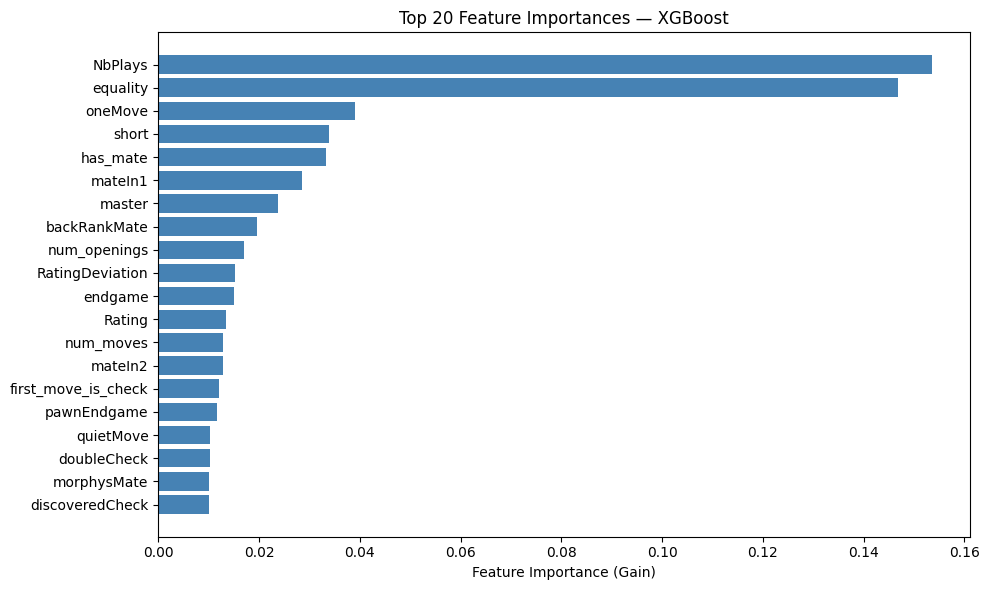

In [28]:
# XGBoost built-in feature importance (gain)
importances = xgb_final.feature_importances_
feat_names = X_train.columns

# Sort and take top 20
idx_sorted = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(idx_sorted)), importances[idx_sorted][::-1], color='steelblue')
ax.set_yticks(range(len(idx_sorted)))
ax.set_yticklabels(feat_names[idx_sorted][::-1])
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()